In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.src.callbacks import early_stopping
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Dense,
    LSTM,
    Conv1D,
    GlobalMaxPooling1D,
    GlobalAveragePooling1D
)

In [2]:
VOCAB_SIZE = 10000
MAX_LEN = 200

print("Loading IMDb dataset...")
# num_words ensures we only keep the top 10k words.
# Words are already integer-encoded by frequency.
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print(f"Training sequences: {len(x_train)}")
print(f"Testing sequences:  {len(x_test)}")

# Pad sequences to ensure uniform input length (MAX_LEN)
print(f"Padding sequences to length {MAX_LEN}...")
x_train_pad = pad_sequences(x_train, maxlen=MAX_LEN, padding='post', truncating='post')
x_test_pad = pad_sequences(x_test, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"x_train shape: {x_train_pad.shape}")

Loading IMDb dataset...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training sequences: 25000
Testing sequences:  25000
Padding sequences to length 200...
x_train shape: (25000, 200)


In [11]:
EMBEDDING_DIM = 32

def build_ann():
    """
    Artificial Neural Network (Dense)
    Averages the embeddings across the entire sequence before passing to a Dense layer.
    Fast, but completely ignores word order.
    """
    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(VOCAB_SIZE, EMBEDDING_DIM, name="embedding"),
        GlobalAveragePooling1D(), # Averages the 200 words into a single 32D vector
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid') # Binary classification
    ], name="Standard_ANN")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_rnn():
    """
    Recurrent Neural Network (LSTM)
    Processes the sequence word-by-word, maintaining a hidden state.
    Excellent at understanding long-term context and word order, but slow to train.
    """
    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(VOCAB_SIZE, EMBEDDING_DIM, name="embedding"),
        LSTM(32), # Returns only the final state after seeing all 200 words
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ], name="LSTM_RNN")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_cnn():
    """
    1D Convolutional Neural Network
    Slides multiple filters across the word sequence to find local patterns (N-grams).
    Much faster than RNNs and highly effective for sentiment detection.
    """
    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(VOCAB_SIZE, EMBEDDING_DIM, name="embedding"),
        # kernel_size=5 means it looks at 5 words at a time
        Conv1D(filters=64, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(), # Extracts the strongest features detected across the sequence
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ], name="1D_CNN")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate models
models = {
    "ANN": build_ann(),
    "RNN": build_rnn(),
    "CNN": build_cnn()
}

for name, model in models.items():
    print(f"\n{name} Model Summary:")
    model.summary()


ANN Model Summary:


Model: "Standard_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,545 (1.22 MB)

 Trainable params: 320,545 (1.22 MB)

...

Model: "1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 196, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,361 (1.26 MB)

 Trainable params: 331,361 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss for early stopping
    patience=5,        # Stop if no improvement after 2 epochs
    restore_best_weights=True # Restore model weights from the epoch with the best validation loss
)

In [13]:
EPOCHS = 25
BATCH_SIZE = 256
histories = {}

for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Training {name}...")
    print(f"{'='*40}")

    history = model.fit(
        x_train_pad, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2, # Monitor 20% of training data for overfitting
        verbose=1,
        callbacks=[early_stopping]
    )
    histories[name] = history


Training ANN...
Epoch 1/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6170 - loss: 0.6848 - val_accuracy: 0.7056 - val_loss: 0.6617
Epoch 2/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7436 - loss: 0.6122 - val_accuracy: 0.7806 - val_loss: 0.5468
Epoch 3/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8138 - loss: 0.4774 - val_accuracy: 0.8308 - val_loss: 0.4301
Epoch 4/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8509 - loss: 0.3798 - val_accuracy: 0.8502 - val_loss: 0.3740
Epoch 5/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8708 - loss: 0.3274 - val_accuracy: 0.8534 - val_loss: 0.3464
Epoch 6/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8863 - loss: 0.2917 - val_accuracy: 0.8644 - val_loss: 0.3278
Epoch 7/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8969 - loss: 0.2666 - val_accuracy: 0.8720 - val_loss: 0.3176
Epoch 8/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9044 - loss: 0.2466 - val_accuracy: 

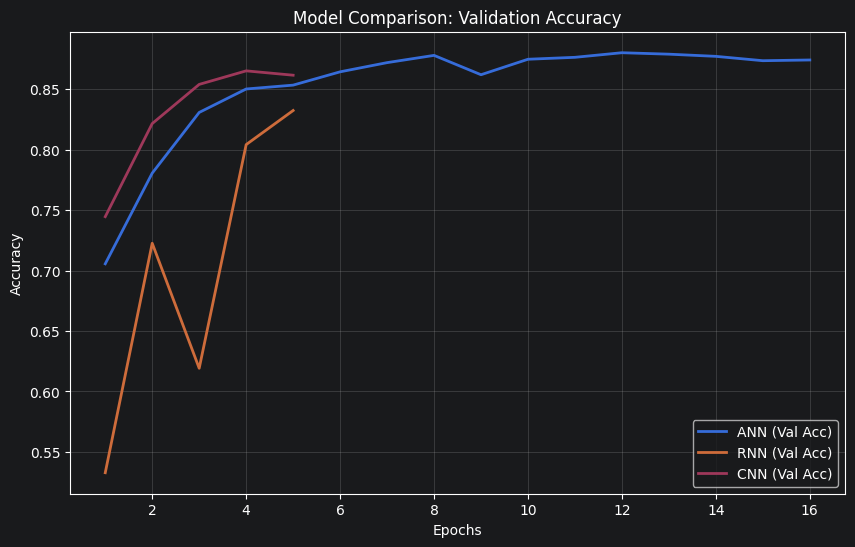


Final Test Set Performance:
ANN  -> Accuracy: 86.38% | Loss: 0.3289
RNN  -> Accuracy: 52.72% | Loss: 0.6916
CNN  -> Accuracy: 74.68% | Loss: 0.5478


In [14]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    # Extract validation accuracy
    val_acc = history.history['val_accuracy']

    # FIX: Dynamically generate the x-axis based on the actual length of val_acc
    epochs_run = len(val_acc)

    plt.plot(range(1, epochs_run + 1), val_acc, label=f"{name} (Val Acc)", linewidth=2)

plt.title("Model Comparison: Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final Test Set Evaluation
print("\nFinal Test Set Performance:")
for name, model in models.items():
    test_loss, test_acc = model.evaluate(x_test_pad, y_test, verbose=0)
    print(f"{name:<4} -> Accuracy: {test_acc*100:.2f}% | Loss: {test_loss:.4f}")